In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
account_df = pd.read_csv("account_clean.csv")
card_df = pd.read_csv("card_clean.csv")
client_df = pd.read_csv("client_clean.csv")
disp_df = pd.read_csv("disp_clean.csv")
district_df = pd.read_csv("district_clean.csv")
loan_df = pd.read_csv("loan_clean.csv")
orders_df = pd.read_csv("orders_clean.csv")
trnx_df = pd.read_csv("transactions_clean.csv")

In [50]:
account_df["date"] = pd.to_datetime(account_df["date"])
loan_df["date"] = pd.to_datetime(loan_df["date"])
trnx_df["date"] =pd.to_datetime(trnx_df["date"])
card_df['issued_date']=pd.to_datetime(card_df['issued_date'])

### Account Level Analysis

In [4]:
account_type_summary = (
    account_df.account_type.value_counts().reset_index()
)

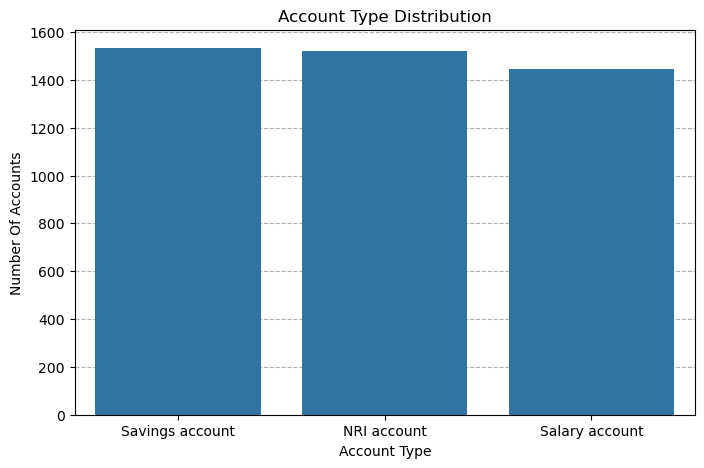

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(data=account_type_summary,x="account_type",y="count",zorder=3)

plt.title("Account Type Distribution")
plt.xlabel("Account Type")
plt.ylabel("Number Of Accounts")

plt.grid(axis="y",linestyle='--')
plt.show()

Savings accounts have the highest representation, followed closely by NRI accounts, while Salary accounts have a slightly lower share. Overall, the account portfolio is relatively balanced across the three account types

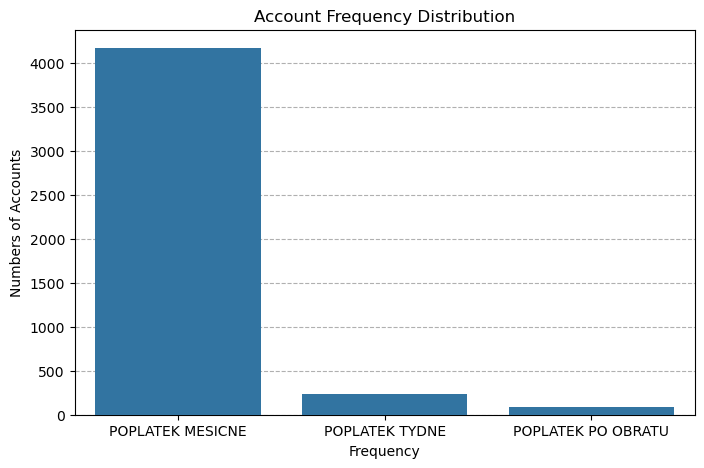

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(data=account_df,x="frequency",zorder=3)

plt.title("Account Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Numbers of Accounts")

plt.grid(axis="y",linestyle='--')
plt.show()

In [7]:
account_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    4500 non-null   int64         
 1   district_id   4500 non-null   int64         
 2   frequency     4500 non-null   object        
 3   date          4500 non-null   datetime64[ns]
 4   account_type  4500 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 175.9+ KB


In [8]:
account_year = account_df["date"].dt.year.value_counts().sort_index()

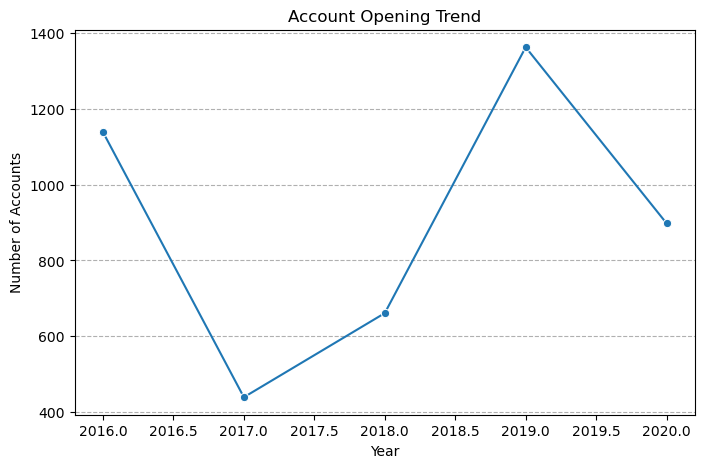

In [9]:
plt.figure(figsize=(8,5))

sns.lineplot(x=account_year.index,y=account_year.values,marker="o")

plt.title("Account Opening Trend")
plt.xlabel("Year")
plt.ylabel("Number of Accounts")

plt.grid(axis="y",linestyle='--')
plt.show()

Account openings fluctuated significantly over the observed period. The highest account acquisition occurred in 1996, while 1994 experienced the lowest number of new accounts.

In [10]:
account_month = account_df.groupby(account_df["date"].dt.to_period('M')).size().rename("count").reset_index()

In [11]:
account_month['date_str'] = account_month['date'].dt.strftime('%m-%Y')

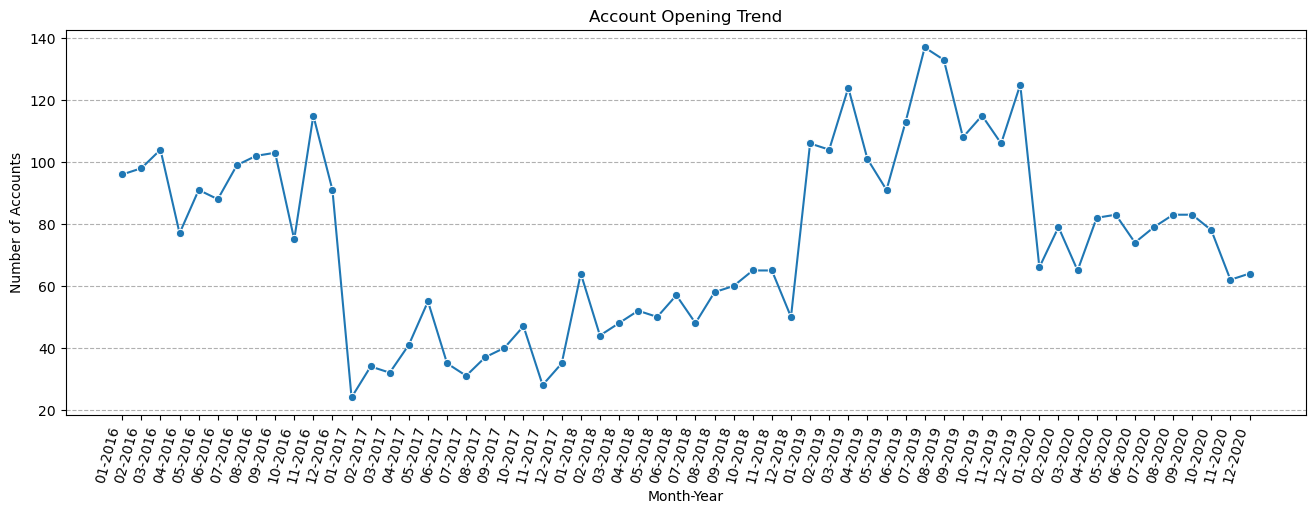

In [12]:
plt.figure(figsize=(16,5))

sns.lineplot(data=account_month,x="date_str",y="count", marker ="o")

plt.title("Account Opening Trend")
plt.xlabel("Month-Year")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=75,ha='right')

plt.grid(axis="y",linestyle='--')
plt.show()

In [13]:
account_district_df = account_df.merge(right=district_df,on='district_id',how='left').iloc[:,:7]

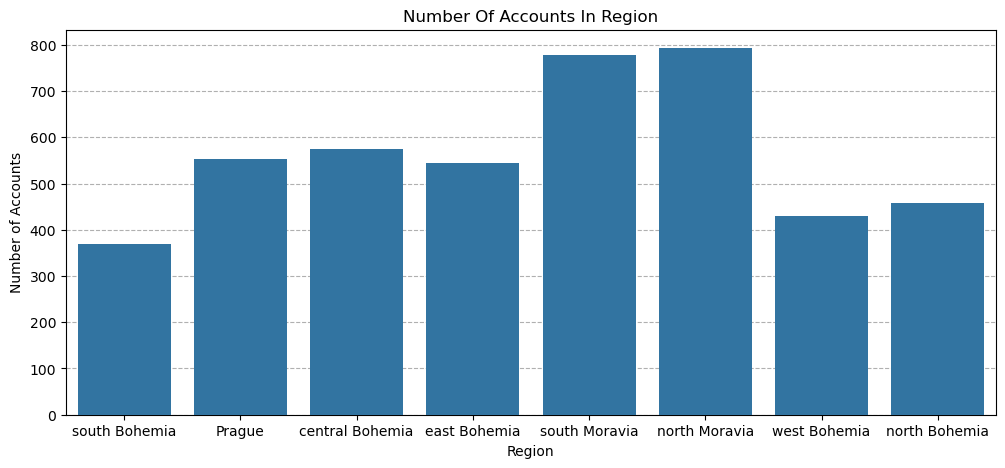

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(data=account_district_df,x='region',zorder=3)

plt.title("Number Of Accounts In Region")
plt.xlabel("Region")
plt.ylabel("Number of Accounts")

plt.grid(axis="y",linestyle='--')
plt.show()

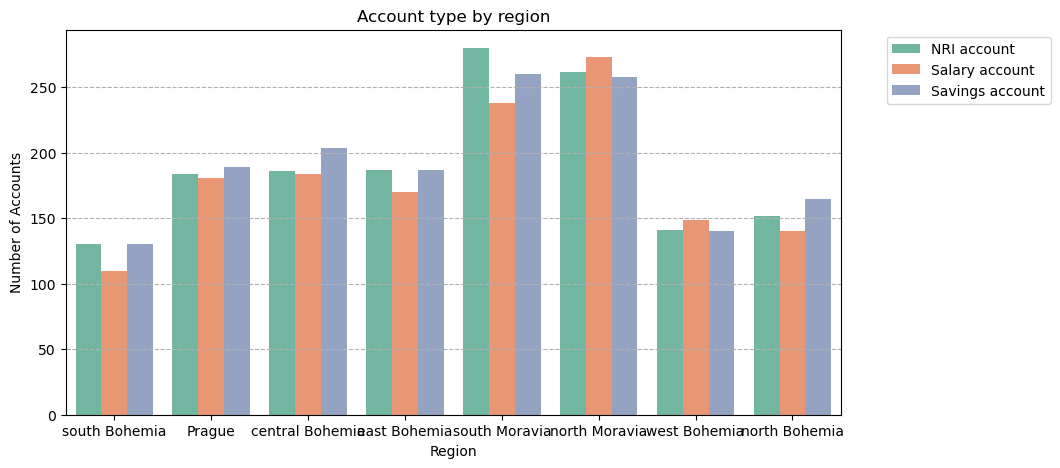

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(data=account_district_df,x='region',hue='account_type',palette='Set2')

plt.title("Account type by region")
plt.xlabel('Region')
plt.ylabel("Number of Accounts")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y",linestyle='--')
plt.show()

### Loan Level Analysis

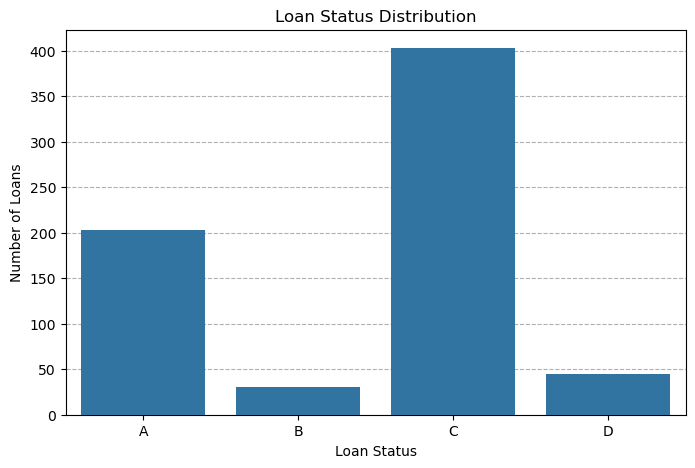

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=loan_df,
    x="status",
    order=["A", "B", "C", "D"] , zorder=3
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--")

plt.show()

##### A → completed successfully
##### B → completed with issues
##### C → running
##### D → running with outstanding debt

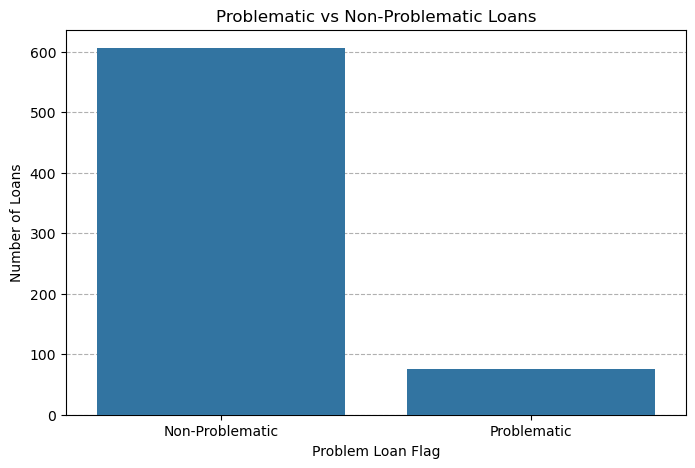

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=loan_df,
    x="problem_loan_flag" , zorder=3
)

plt.title("Problematic vs Non-Problematic Loans")
plt.xlabel("Problem Loan Flag")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["Non-Problematic", "Problematic"])
plt.grid(axis="y", linestyle="--")

plt.show()

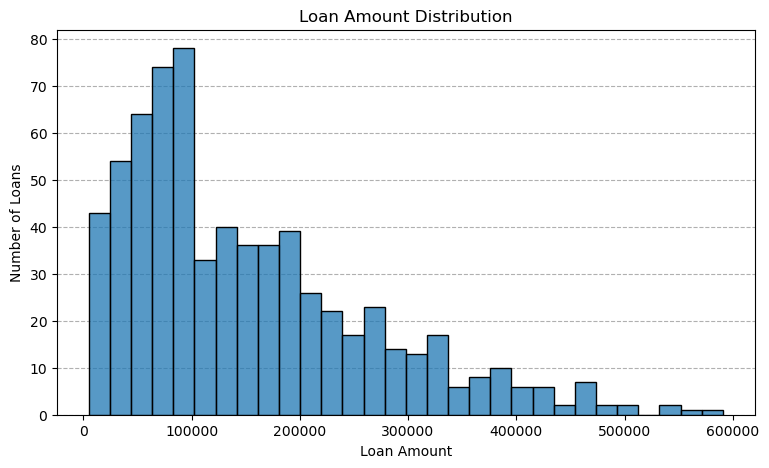

In [18]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=loan_df,
    x="amount",
    bins=30 , zorder=3
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--")

plt.show()

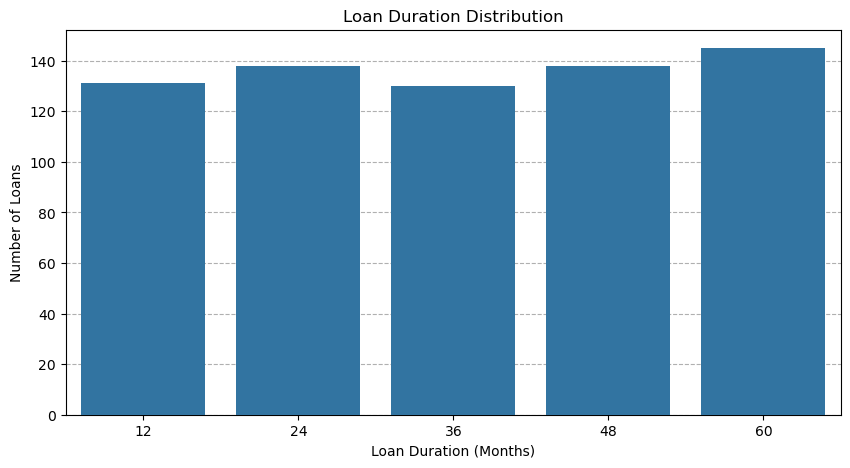

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(data=loan_df,
             x='duration',
              zorder=3
             )
plt.title("Loan Duration Distribution")
plt.xlabel("Loan Duration (Months)")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--")

plt.show()

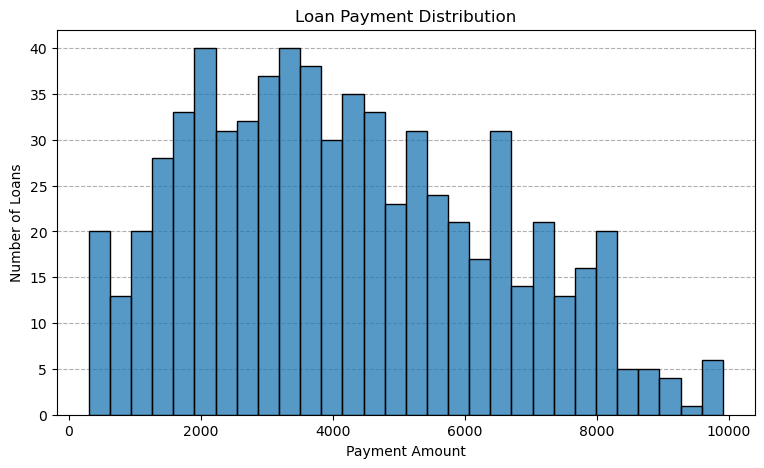

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=loan_df,
    x="payments",
    bins=30 , zorder=3
)

plt.title("Loan Payment Distribution")
plt.xlabel("Payment Amount")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--")

plt.show()

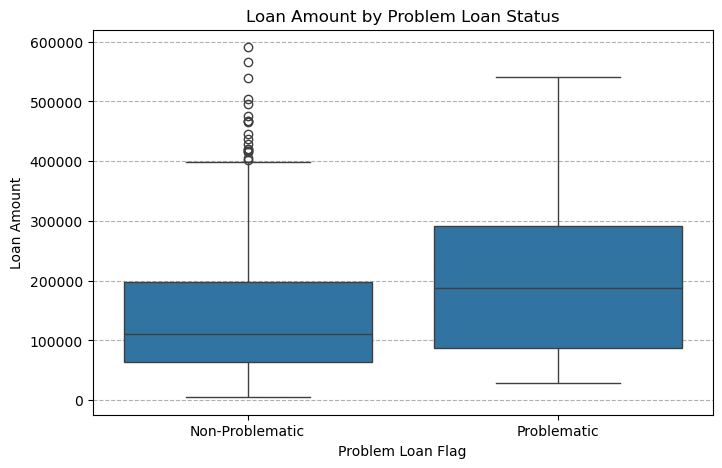

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=loan_df,
    x="problem_loan_flag",
    y="amount"
)

plt.title("Loan Amount by Problem Loan Status")
plt.xlabel("Problem Loan Flag")
plt.ylabel("Loan Amount")
plt.xticks(
    [0, 1],
    ["Non-Problematic", "Problematic"]
)
plt.grid(axis="y", linestyle="--")

plt.show()

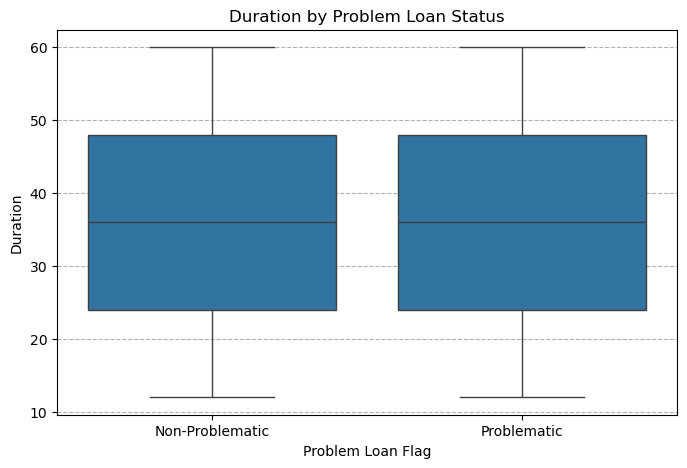

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=loan_df,
    x="problem_loan_flag",
    y="duration"
)

plt.title("Duration by Problem Loan Status")
plt.xlabel("Problem Loan Flag")
plt.ylabel("Duration")
plt.xticks(
    [0, 1],
    ["Non-Problematic", "Problematic"]
)
plt.grid(axis="y", linestyle="--")

plt.show()

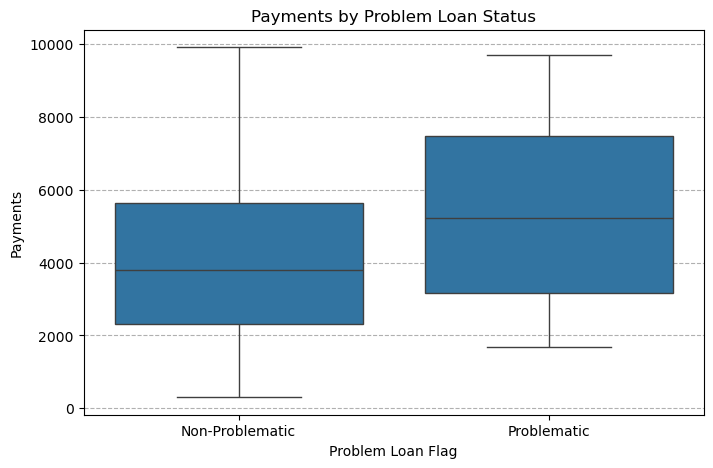

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=loan_df,
    x="problem_loan_flag",
    y="payments"
)

plt.title("Payments by Problem Loan Status")
plt.xlabel("Problem Loan Flag")
plt.ylabel("Payments")
plt.xticks(
    [0, 1],
    ["Non-Problematic", "Problematic"]
)
plt.grid(axis="y", linestyle="--")

plt.show()

In [24]:
loan_year_summary = (loan_df["loan_year"].value_counts().sort_index())

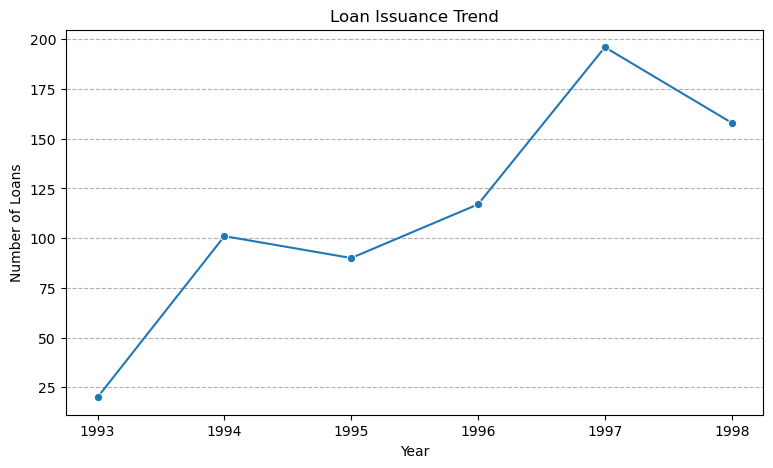

In [25]:
plt.figure(figsize=(9,5))

sns.lineplot(
    x=loan_year_summary.index,
    y=loan_year_summary.values,
    marker="o"
)

plt.title("Loan Issuance Trend")
plt.xlabel("Year")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--")

plt.show()

In [26]:
loan_year_risk = loan_df.groupby("loan_year").agg(total_loans=("loan_id","count"),problematic_loans=("problem_loan_flag","sum"))
loan_year_risk["problematic_loan_rate"]=(loan_year_risk.problematic_loans/loan_year_risk.total_loans)*100
loan_year_risk

,total_loans,problematic_loans,problematic_loan_rate
loan_year,,,
1993,20,4,20.000000
1994,101,14,13.861386
1995,90,12,13.333333
1996,117,16,13.675214
1997,196,26,13.265306
1998,158,4,2.531646


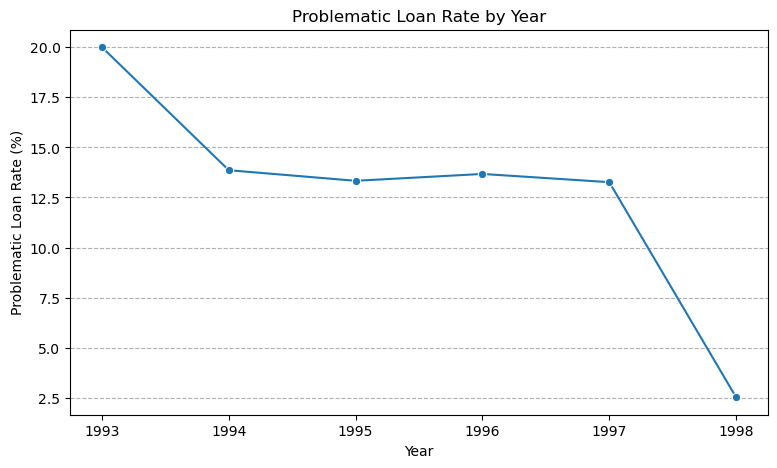

In [27]:
plt.figure(figsize=(9,5))

sns.lineplot(
    data=loan_year_risk,
    x=loan_year_risk.index,
    y="problematic_loan_rate",
    marker="o"
)

plt.title("Problematic Loan Rate by Year")
plt.xlabel("Year")
plt.ylabel("Problematic Loan Rate (%)")
plt.grid(axis="y", linestyle="--")

plt.show()

In [28]:
transaction_year_summary = (trnx_df.groupby("trnx_year").agg(total_transactions=("trans_id", "count"),total_transaction_value=("amount", "sum")))

transaction_year_summary.astype(int)

,total_transactions,total_transaction_value
trnx_year,,
2016,28205,204309987
2017,91628,538796646
2018,133022,767739197
2019,196779,1163864249
2020,284409,1688347890
2021,314532,1867735412


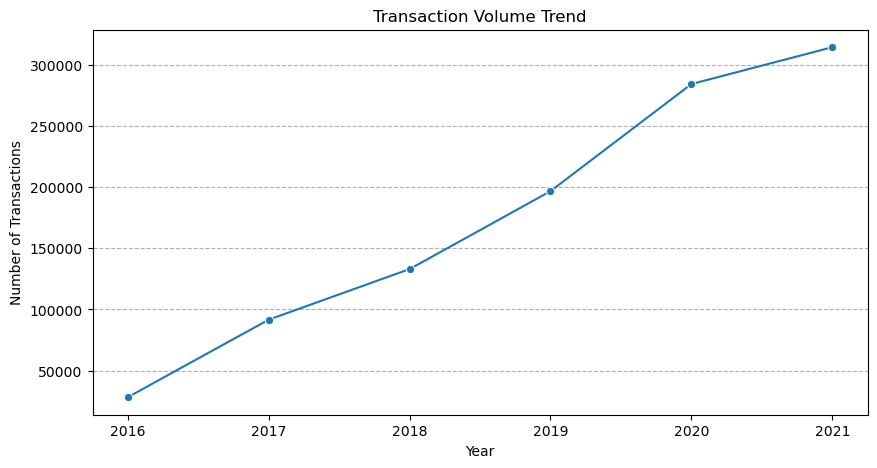

In [29]:
plt.figure(figsize=(10,5))

sns.lineplot(data=transaction_year_summary,
            x=transaction_year_summary.index,
            y='total_transactions',marker="o")
plt.title("Transaction Volume Trend")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linestyle="--")

plt.show()

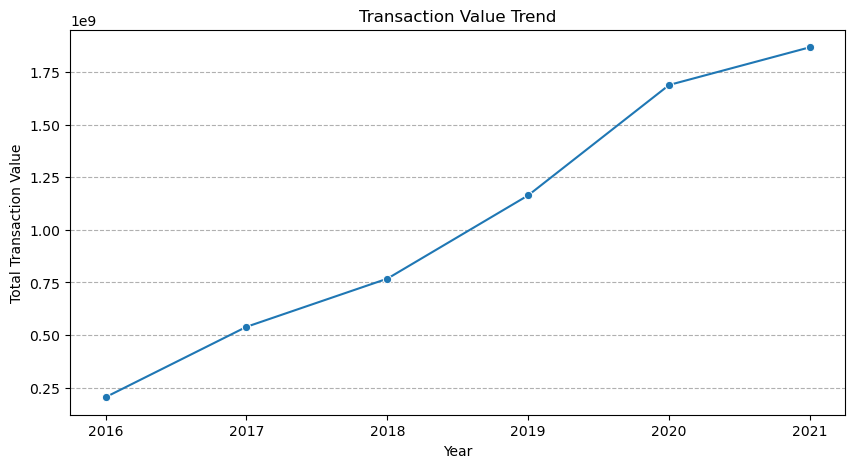

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(data=transaction_year_summary,
            x=transaction_year_summary.index,
            y='total_transaction_value',marker="o")
plt.title("Transaction Value Trend")
plt.xlabel("Year")
plt.ylabel("Total Transaction Value")

plt.grid(axis="y", linestyle="--")

plt.show()

In [31]:
transaction_type_summary = (
    trnx_df
    .groupby("type")
    .agg(
        transaction_count=("trans_id", "count"),
        total_value=("amount", "sum")
    )
)

transaction_type_summary.astype(int)

,transaction_count,total_value
type,,
Credit,400209,3216335973
Withdrawal,648366,3014457408


In [32]:
operation_summary = trnx_df.groupby("operation").agg(transaction_count=("trans_id","count"),
     total_value = ("amount","sum")).sort_values("transaction_count",ascending=False)
operation_summary.astype(int)

,transaction_count,total_value
operation,,
Withdrawal in cash,432377,2324392424
Remittance to Another Bank,208283,672638484
Interest Credit,178663,26676390
Credit in cash,156320,2408179630
Electronic funds transfer,65226,781479953
Credit card withdrawal,7706,17426500


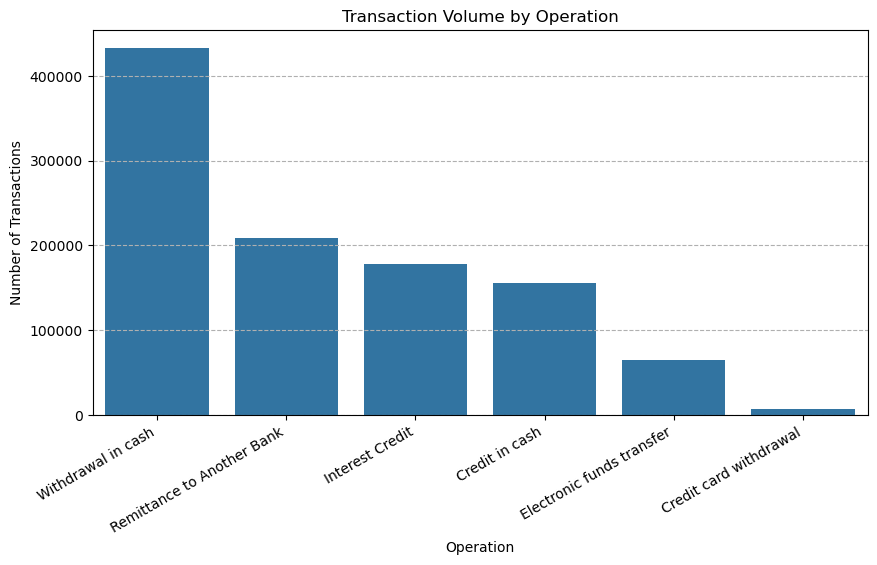

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=operation_summary.reset_index(),
    x="operation",
    y="transaction_count"
)

plt.title("Transaction Volume by Operation")
plt.xlabel("Operation")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--")

plt.show()

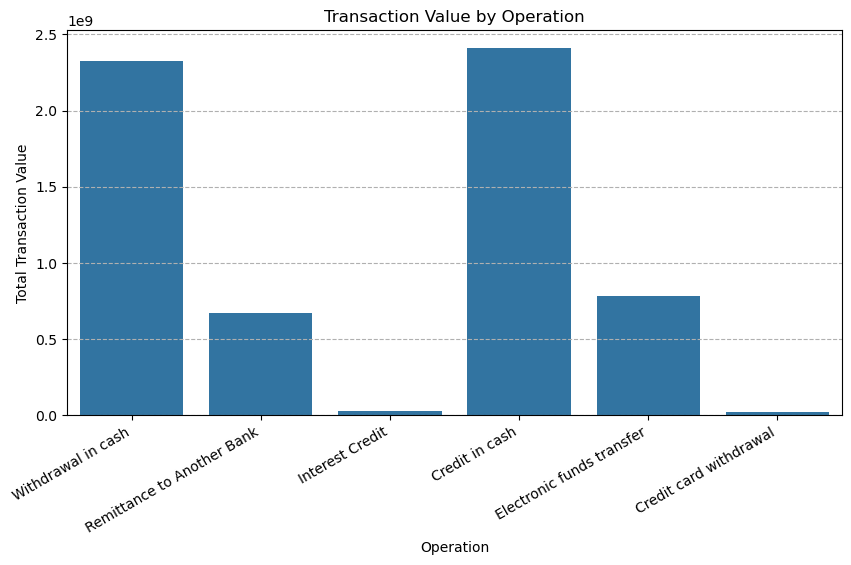

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=operation_summary.reset_index(),
    x="operation",
    y="total_value"
)

plt.title("Transaction Value by Operation")
plt.xlabel("Operation")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--")

plt.show()

In [35]:
type_year_summary = trnx_df.groupby(['trnx_year','type']).agg(transaction_count=("trans_id","count"),
                                         total_value=("amount","sum")).reset_index()
type_year_summary

,trnx_year,type,transaction_count,total_value
0,2016,Credit,15212,120442617.0
1,2016,Withdrawal,12993,83867370.0
2,2017,Credit,35743,278536213.0
3,2017,Withdrawal,55885,260260433.0
4,2018,Credit,50633,396068569.0
5,2018,Withdrawal,82389,371670628.0
6,2019,Credit,76964,606772930.0
7,2019,Withdrawal,119815,557091319.0
8,2020,Credit,107678,864695012.0
9,2020,Withdrawal,176731,823652878.0


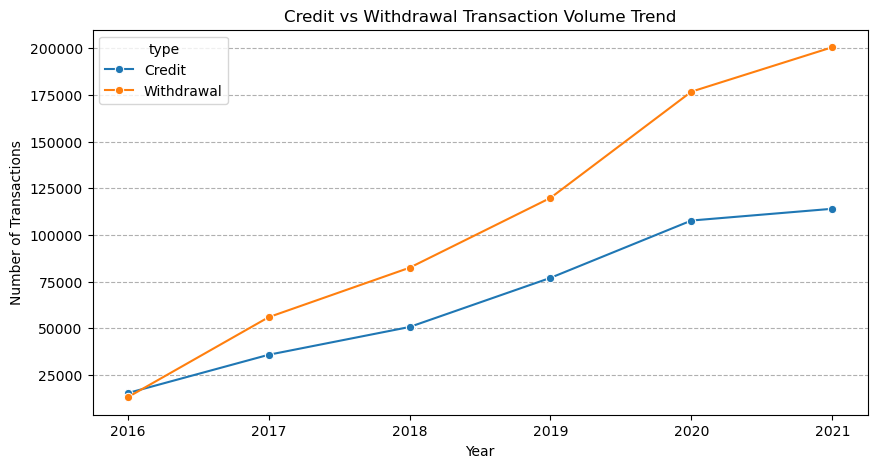

In [36]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=type_year_summary,
    x="trnx_year",
    y="transaction_count",
    hue="type",
    marker="o"
)

plt.title("Credit vs Withdrawal Transaction Volume Trend")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", linestyle="--")

plt.show()

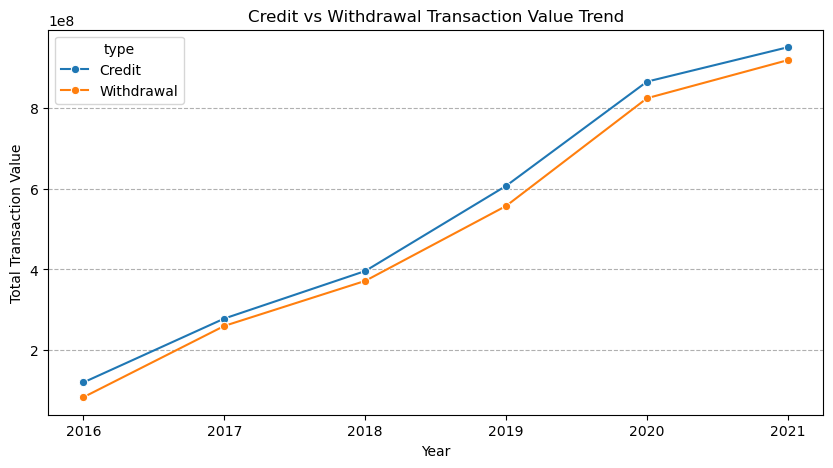

In [37]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=type_year_summary,
    x="trnx_year",
    y="total_value",
    hue="type",
    marker="o"
)

plt.title("Credit vs Withdrawal Transaction Value Trend")
plt.xlabel("Year")
plt.ylabel("Total Transaction Value")
plt.grid(axis="y", linestyle="--")

plt.show()

In [38]:
trnx_df.groupby("type").agg(totaltransaction_count=("trans_id","count"),
                           total_value=("amount","sum"),
                           avg_trnx_value = ("amount","mean")).astype(int)

,totaltransaction_count,total_value,avg_trnx_value
type,,,
Credit,400209,3216335973,8036
Withdrawal,648366,3014457408,4649


In [39]:
trnx_df["amount"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

0.50     2100.0
0.75     6817.0
0.90    18467.0
0.95    25756.0
0.99    45463.0
Name: amount, dtype: float64

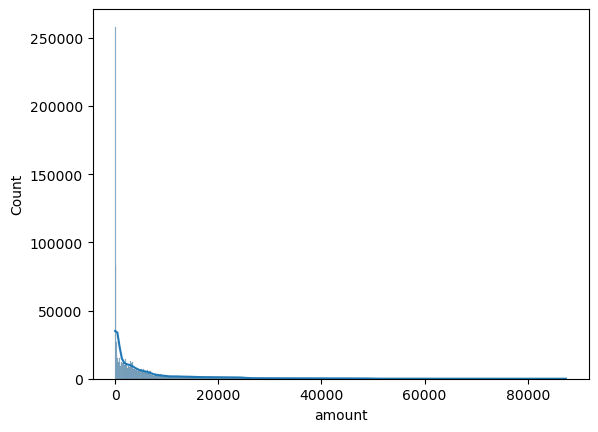

In [40]:
sns.histplot(data=trnx_df,x="amount",kde=True)

plt.show()

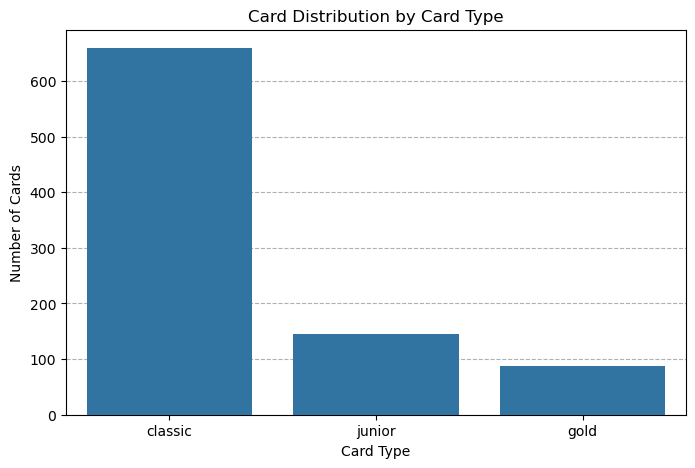

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=card_df,
    x="type",
    order=card_df["type"].value_counts().index,
    zorder=3
)

plt.title("Card Distribution by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Number of Cards")
plt.grid(axis="y", linestyle="--")

plt.show()

In [51]:
card_df["issue_year"] = card_df["issued_date"].dt.year

In [53]:
card_issuance_yearly = (
    card_df.groupby("issue_year")
    .size()
    .reset_index(name="card_count")
)

card_issuance_yearly

,issue_year,card_count
0,2016,1
1,2017,21
2,2018,63
3,2019,116
4,2020,242
5,2021,449


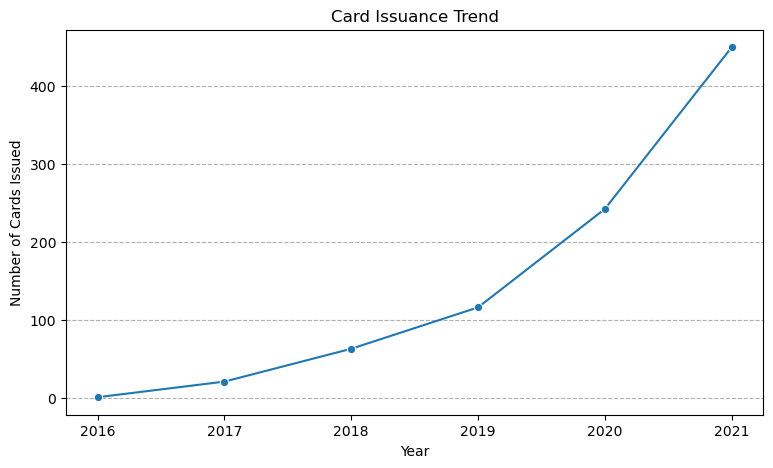

In [54]:
plt.figure(figsize=(9,5))

sns.lineplot(
    data=card_issuance_yearly,
    x="issue_year",
    y="card_count",
    marker="o"
)

plt.title("Card Issuance Trend")
plt.xlabel("Year")
plt.ylabel("Number of Cards Issued")
plt.grid(axis="y", linestyle="--")

plt.show()

In [55]:
card_type_yearly = (
    card_df.groupby(["issue_year", "type"])
    .size()
    .reset_index(name="card_count")
)

card_type_yearly

,issue_year,type,card_count
0,2016,classic,1
1,2017,classic,17
2,2017,junior,4
3,2018,classic,42
4,2018,gold,4
5,2018,junior,17
6,2019,classic,83
7,2019,gold,5
8,2019,junior,28
9,2020,classic,190


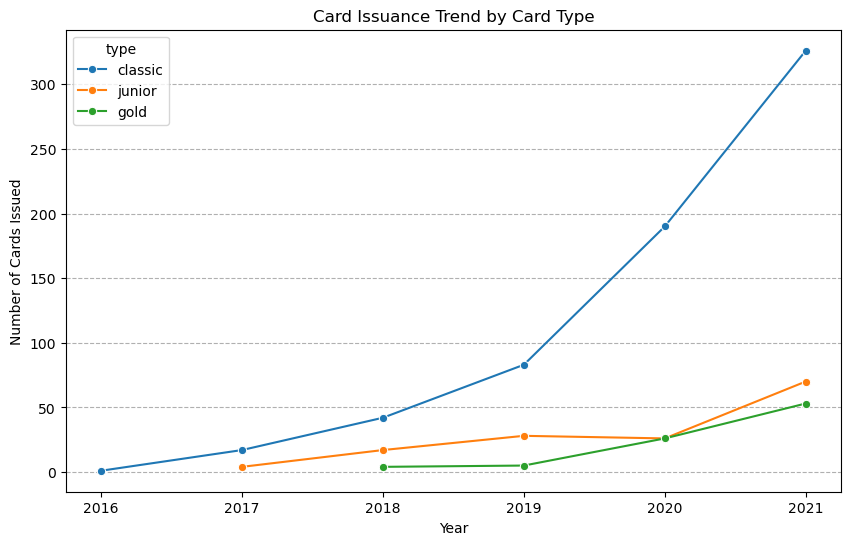

In [56]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=card_type_yearly,
    x="issue_year",
    y="card_count",
    hue="type",
    marker="o"
)

plt.title("Card Issuance Trend by Card Type")
plt.xlabel("Year")
plt.ylabel("Number of Cards Issued")
plt.grid(axis="y", linestyle="--")

plt.show()